In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df=pd.read_csv('pelanggan.csv')

In [6]:
df

,Id_custommer,usia,bulanan,Lama_berlangganan,Hilang_pelanggan
0,1,25,200,1,0
1,2,30,150,2,0
2,3,45,400,8,1
3,4,35,350,6,0
4,5,40,300,7,1
5,6,50,500,10,1
6,7,29,220,2,0
7,8,60,100,12,1


# Menampilkan 5 baris pertama

In [5]:

df.head()


,Id_custommer,usia,bulanan,Lama_berlangganan,Hilang_pelanggan
0,1,25,200,1,0
1,2,30,150,2,0
2,3,45,400,8,1
3,4,35,350,6,0
4,5,40,300,7,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id_custommer       8 non-null      int64
 1   usia               8 non-null      int64
 2   bulanan            8 non-null      int64
 3   Lama_berlangganan  8 non-null      int64
 4   Hilang_pelanggan   8 non-null      int64
dtypes: int64(5)
memory usage: 452.0 bytes


# Statistik deskriptif

In [8]:
df.describe()

,Id_custommer,usia,bulanan,Lama_berlangganan,Hilang_pelanggan
count,8.00000,8.00000,8.0000,8.000000,8.000000
mean,4.50000,39.25000,277.5000,6.000000,0.500000
std,2.44949,11.90138,134.8809,4.035556,0.534522
min,1.00000,25.00000,100.0000,1.000000,0.000000
25%,2.75000,29.75000,187.5000,2.000000,0.000000
50%,4.50000,37.50000,260.0000,6.500000,0.500000
75%,6.25000,46.25000,362.5000,8.500000,1.000000
max,8.00000,60.00000,500.0000,12.000000,1.000000


# Cek distribusi hilang pelanggan

In [9]:
df['Hilang_pelanggan'].value_counts()

Hilang_pelanggan
0    4
1    4
Name: count, dtype: int64

# Visualisasi distribusi pelanggan_hilang:

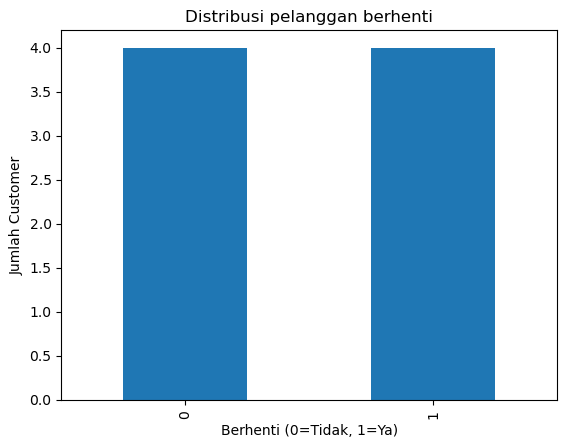

In [10]:
df['Hilang_pelanggan'].value_counts().plot(kind='bar')
plt.title("Distribusi pelanggan berhenti")
plt.xlabel("Berhenti (0=Tidak, 1=Ya)")
plt.ylabel("Jumlah Customer")
plt.show()


# Hubungan antara pengeluaran bulanan dan Hilang_pelanggan

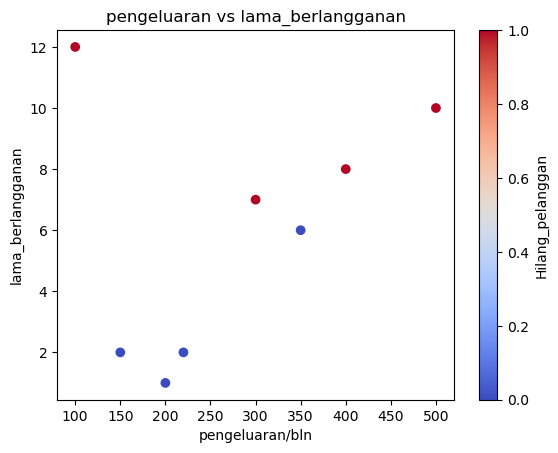

In [11]:
plt.scatter(df['bulanan'], df['Lama_berlangganan'], c=df['Hilang_pelanggan'], cmap='coolwarm')
plt.title("pengeluaran vs lama_berlangganan")
plt.xlabel("pengeluaran/bln")
plt.ylabel("lama_berlangganan")
plt.colorbar(label="Hilang_pelanggan")
plt.show()


# Langkah 2: DATA COLLECTION
# ----------------------------
# Contoh: Mengimpor data penjualan dari file CSV (bisa diganti dengan URL atau API)
# Misal kamu punya file: "penjualan2.csv"

In [3]:
data=pd.read_csv('penjualan2.csv')

In [4]:
data

,Tanggal,Produk,Kategori,Jumlah,Harga
0,01-10-25,Laptop,Elektronik,2,7500000.0
1,02-10-25,Mouse,Aksesoris,5,120000.0
2,03-10-25,Keyboard,Aksesoris,3,250000.0
3,04-10-25,Monitor,Elektronik,1,2000000.0
4,05-10-25,Laptop,Elektronik,1,NaN


In [5]:
# Langkah 2: CEK MISSING VALUE
print("\n🔍 Jumlah Missing Values:")
print(data.isnull().sum())


🔍 Jumlah Missing Values:
Tanggal     0
Produk      0
Kategori    0
Jumlah      0
Harga       1
dtype: int64


In [6]:
# Langkah 5: DATA PREPARATION
# ----------------------------

# 5.1 Menghapus kolom yang tidak dibutuhkan
if 'Unnamed: 0' in data.columns:
    data = data.drop(columns=['Unnamed: 0'])

In [7]:
# 5.2 Mengisi missing value dengan nilai median atau modus
data['Harga'] = data['Harga'].fillna(data['Harga'].median())
data['Kategori'] = data['Kategori'].fillna(data['Kategori'].mode()[0])

In [8]:
# 5.3 Menghapus duplikasi data
data = data.drop_duplicates()

In [10]:
# 5.5 Menambahkan kolom baru (contoh: Total)
data['Total'] = data['Jumlah'] * data['Harga']

In [11]:
# Langkah 6: CEK HASIL AKHIR
print("\n✅ Data setelah dibersihkan:")
print(data.head())

print("\n✅ Jumlah data akhir:", len(data))


✅ Data setelah dibersihkan:
     Tanggal    Produk    Kategori  Jumlah      Harga       Total
0 2025-01-10    Laptop  Elektronik       2  7500000.0  15000000.0
1 2025-02-10     Mouse   Aksesoris       5   120000.0    600000.0
2 2025-03-10  Keyboard   Aksesoris       3   250000.0    750000.0
3 2025-04-10   Monitor  Elektronik       1  2000000.0   2000000.0
4 2025-05-10    Laptop  Elektronik       1  1125000.0   1125000.0

✅ Jumlah data akhir: 5


In [12]:
# Langkah 7: Simpan data hasil cleaning
data.to_csv("data_penjualan_bersih.csv", index=False)
print("\n💾 Data bersih disimpan ke 'data_penjualan_bersih.csv'")


💾 Data bersih disimpan ke 'data_penjualan_bersih.csv'


In [13]:
data2=pd.read_csv('data_penjualan_bersih.csv')

In [14]:
data2

,Tanggal,Produk,Kategori,Jumlah,Harga,Total
0,2025-01-10,Laptop,Elektronik,2,7500000.0,15000000.0
1,2025-02-10,Mouse,Aksesoris,5,120000.0,600000.0
2,2025-03-10,Keyboard,Aksesoris,3,250000.0,750000.0
3,2025-04-10,Monitor,Elektronik,1,2000000.0,2000000.0
4,2025-05-10,Laptop,Elektronik,1,1125000.0,1125000.0
